loan approval - xgboost
-----------------------------------
accuracy: 0.7
-----------------------------------
feature importance:
assets          0.1952
income          0.1931
credit_score    0.1867
loan_amount     0.1565
employed        0.1389
age             0.1297
dtype: float32


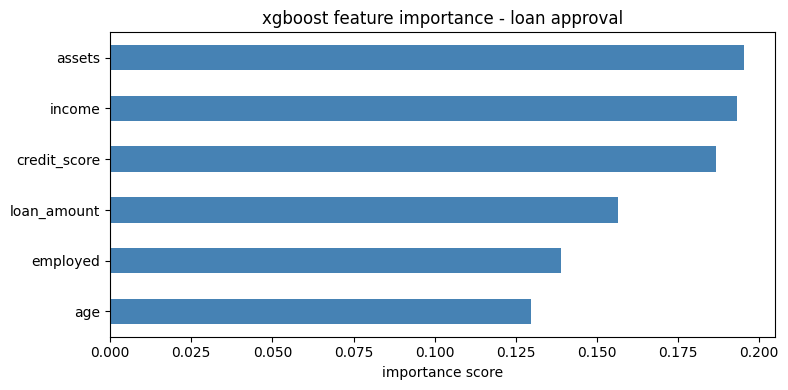

In [3]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200

data = {
    "age":          np.random.randint(21, 60, n),
    "income":       np.random.randint(15000, 200000, n),
    "credit_score": np.random.randint(300, 900, n),
    "loan_amount":  np.random.randint(50000, 1000000, n),
    "employed":     np.random.choice([0, 1], n),
    "assets":       np.random.randint(0, 5000000, n),
    "approved":     np.random.choice([0, 1], n, p=[0.35, 0.65])
}

df = pd.DataFrame(data)
x = df.drop("approved", axis=1)
y = df["approved"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

model = xgb.XGBClassifier(n_estimators=100,
                           random_state=42,
                           eval_metric="logloss",
                           verbosity=0)
model.fit(x_train, y_train)

print("loan approval - xgboost")
print("-" * 35)
print("accuracy:", round(model.score(x_test, y_test), 3))
print("-" * 35)

importance = pd.Series(
    model.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

print("feature importance:")
print(importance.round(4))

importance.sort_values().plot(kind="barh",
                               color="steelblue",
                               figsize=(8, 4))
plt.title("xgboost feature importance - loan approval")
plt.xlabel("importance score")
plt.tight_layout()
plt.show()